In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
#%matplotlib notebook
#%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
import json
from typing import Dict, Optional, Tuple, List
import random

class Parameter:
    def __init__(self, name: str, value: float, range: Optional[Tuple[float, float]] = None, distribution: Optional[str] = None, **distribution_params):
        """
        Unified class for a parameter.

        :param name: Name of the parameter
        :param value: Value of the parameter
        :param range: Range of the parameter (optional)
        :param distribution: Distribution of the parameter (optional)
        :param distribution_params: Additional parameters for the distribution
        """
        self.name = name
        self.value = value
        self.range = range
        self.type = "Constant" if range is None else "Variable"
        self.distribution = distribution or ("uniform" if self.type == "Variable" else None)
        self.distribution_params = distribution_params

    def set_type(self, new_type: str):
        """
        Change the type of the parameter to "Constant" or "Variable".

        :param new_type: The new type to set ("Constant" or "Variable").
        """
        if new_type not in ["Constant", "Variable"]:
            raise ValueError("Type must be 'Constant' or 'Variable'")

        self.type = new_type

        if self.type == "Constant":
            self.range = None
            self.distribution = None
        elif self.type == "Variable" and not self.distribution:
            self.distribution = "uniform"

    def to_dict(self) -> Dict:
        """Convert the parameter to a dictionary."""
        return {
            "name": self.name,
            "value": self.value,
            "range": self.range,
            "type": self.type,
            "distribution": self.distribution,
            "distribution_params": self.distribution_params
        }

    @classmethod
    def from_dict(cls, data: Dict):
        """Create a Parameter instance from a dictionary."""
        return cls(
            name=data["name"],
            value=data["value"],
            range=data.get("range"),
            distribution=data.get("distribution"),
            **data.get("distribution_params", {})
        )

    def to_json(self) -> str:
        """Serialize the parameter to a JSON string."""
        return json.dumps(self.to_dict(), indent=4)

    @classmethod
    def from_json(cls, json_str: str):
        """Create a Parameter instance from a JSON string."""
        data = json.loads(json_str)
        return cls.from_dict(data)

    def generate_value(self) -> float:
        """
        Generate a value based on the defined distribution within the range.
        """
        if self.type == "Constant" or not self.range or not self.distribution:
            return self.value

        min_val, max_val = self.range

        if self.distribution == "normal":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            std_dev = self.distribution_params.get("std_dev", (max_val - min_val) / 6)
            return max(min(random.gauss(mean, std_dev), max_val), min_val)

        elif self.distribution == "truncated_gauss":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            std_dev = self.distribution_params.get("std_dev", (max_val - min_val) / 6)
            value = random.gauss(mean, std_dev)
            while not (min_val <= value <= max_val):
                value = random.gauss(mean, std_dev)
            return value

        elif self.distribution == "weibull":
            scale = self.distribution_params.get("scale", (max_val - min_val) / 2)
            shape = self.distribution_params.get("shape", 1.5)
            return max(min(min_val + random.weibullvariate(scale, shape), max_val), min_val)

        elif self.distribution == "uniform":
            return random.uniform(min_val, max_val)

        elif self.distribution == "exponential":
            rate = self.distribution_params.get("rate", 1.0)
            return max(min_val, min(random.expovariate(rate), max_val))

        elif self.distribution == "lognormal":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            sigma = self.distribution_params.get("sigma", (max_val - min_val) / 6)
            return max(min_val, min(random.lognormvariate(mean, sigma), max_val))

        elif self.distribution == "beta":
            alpha = self.distribution_params.get("alpha", 2.0)
            beta = self.distribution_params.get("beta", 5.0)
            return min_val + (random.betavariate(alpha, beta) * (max_val - min_val))

        elif self.distribution == "gamma":
            shape = self.distribution_params.get("shape", 2.0)
            scale = self.distribution_params.get("scale", 1.0)
            return max(min_val, min(random.gammavariate(shape, scale), max_val))

        elif self.distribution == "cauchy":
            location = self.distribution_params.get("location", (min_val + max_val) / 2)
            scale = self.distribution_params.get("scale", (max_val - min_val) / 4)
            value = random.uniform(location - scale, location + scale)
            return max(min_val, min(value, max_val))

        else:
            raise ValueError(f"Unsupported distribution: {self.distribution}")

    def sample_value(self) -> float:
        """
        Sample and update the value based on the defined distribution.
        """
        if self.type == "Constant":
            return self.value
        self.value = self.generate_value()
        return self.value

    def sample_values(self, n: int) -> List[float]:
        """
        Generate n sampled values based on the defined distribution.
        """
        if self.type == "Constant":
            return [self.value] * n
        return [self.generate_value() for _ in range(n)]

# Beispiel: Parameter erstellen und als JSON speichern
param_constant = Parameter(name="constant_param", value=10.0)
print(param_constant.to_json())

param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0))
print(param_variable.to_json())

param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="truncated_gauss",
    mean=5.0,
    std_dev=1.0
)
print(param_distributed.to_json())

# Sampling von mehreren Werten
sampled_values = param_distributed.sample_values(10)
print(f"Sampled values: {sampled_values}")

# Typänderung
param_distributed.set_type("Constant")
print(param_distributed.to_json())

# Sampling nach Typänderung
sampled_values_constant = param_distributed.sample_values(10)
print(f"Sampled values after type change: {sampled_values_constant}")

# JSON-Import
loaded_param = Parameter.from_json(param_distributed.to_json())
print(loaded_param.to_dict())

{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "type": "Constant",
    "distribution": null,
    "distribution_params": {}
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": "uniform",
    "distribution_params": {}
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "distribution": "truncated_gauss",
    "distribution_params": {
        "mean": 5.0,
        "std_dev": 1.0
    }
}
Sampled values: [4.3430757854041735, 5.881653281896333, 4.999140743389638, 5.513081171194443, 6.254041631976422, 3.7622151115400717, 5.323395590018229, 5.97894188451846, 4.817154592448967, 4.306666073157078]
{
    "name": "distributed_param",
    "value": 5.0,
    "range": null,
    "type": "Constant",
    "distribution": null,
    "distribution_params": {
        "mean": 5.0,
        "std_dev": 1.0
    }
}
Sampled

In [29]:
param_constant.sample_values(10)

[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

In [30]:
param_variable.sample_values(10)

[3.2288197217209404,
 3.58441146087654,
 6.782290819011916,
 3.227749891770965,
 8.990818689570329,
 2.6103247862758785,
 1.7284143831440868,
 2.5436121421407543,
 8.974300707663653,
 6.679707579085954]

In [31]:
param_distributed.sample_values(10)

[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

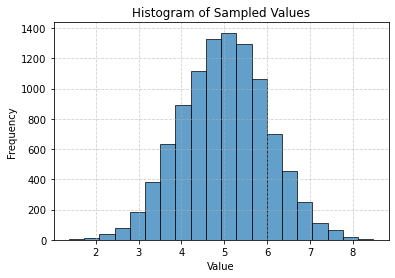

In [32]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="truncated_gauss",
    mean=5.0,
    std_dev=1.0
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


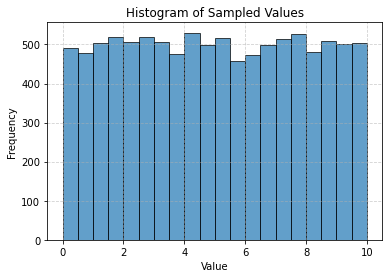

In [33]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="uniform",
    mean=5.0,
    std_dev=1.0
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


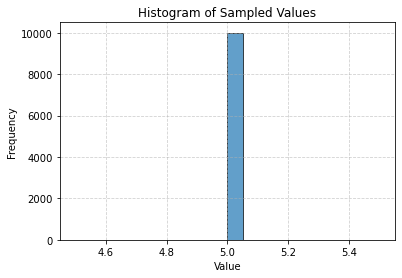

In [34]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="truncated_gauss",
    mean=5.0,
    std_dev=1.0
)
param_distributed.type = "Constant"
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

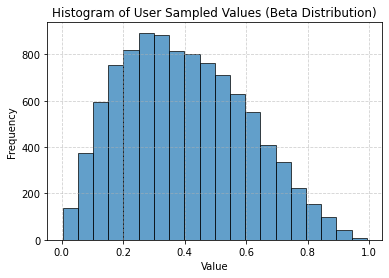

In [43]:
# Beispiel mit einer Beta-Verteilung
user_param = Parameter(
    name="user_distributed_param",
    value=0.5,  # Initialwert
    range=(0.0, 1.0),  # Wertebereich
    distribution="beta",
    alpha=2.0,  # Alpha-Parameter der Beta-Verteilung
    beta=3.0    # Beta-Parameter der Beta-Verteilung
)

# JSON-Export
#print(user_param.to_json())

# Sampling von mehreren Werten
user_sampled_values = user_param.sample_values(10000)
#print(f"User sampled values: {user_sampled_values}")

# Plot als Histogramm
import matplotlib.pyplot as plt

plt.hist(user_sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of User Sampled Values (Beta Distribution)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
